# Gradient Pattern Analysis (GPA) — Gradient Extraction and Asymmetry Inspection

## Author

**Carlos Eduardo Falandes**

M.Sc. Candidate in Applied Computing  
National Institute for Space Research (INPE), Brazil

**Master's Dissertation:**  
*Gradient Pattern Analysis (GPA): Two New Applications for Pattern Characterization in Physics of Extreme Events and Extragalactic Astronomy*

**Contact:**  
carloseduardofalandes@gmail.com

This notebook provides a visual inspection of the main steps of the Gradient Pattern Analysis (GPA) method.

It focuses on:

- scalar-field visualization;
- gradient extraction;
- asymmetric gradient selection;
- removed and remaining vectors;
- vectorial diversity ($D$);
- the $G_2$ parameter;
- GPA gradient-field visualizations.

In [12]:
# !pip install git+https://github.com/Desduh/gpa.gitx

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from gpa import GPA

## Matrix visualization

A helper function is created to visualize the synthetic patterns.

Each matrix element represents the intensity value of a spatial position.

In [14]:
def plot_matrix(matrix, title):
    plt.figure(figsize=(5, 5))

    plt.imshow(
        matrix,
        cmap="viridis",
        origin="lower"
    )

    plt.title(title)

    plt.xticks(range(matrix.shape[1]))
    plt.yticks(range(matrix.shape[0]))

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            plt.text(
                j,
                i,
                str(matrix[i, j]),
                ha="center",
                va="center",
                color="white",
                fontsize=10
            )

    plt.show()

## Asymmetric Pattern

The asymmetric pattern is generated by randomly distributing values inside the matrix.

This creates a spatial structure without a predefined organization or symmetry.

The objective is to evaluate how GPA describes irregular spatial distributions.

In [15]:
def create_asymmetric_matrix(n, seed=None):
    """
    Creates an n x n matrix with values from 0 to n²-1
    randomly distributed.
    """
    rng = np.random.default_rng(seed)

    values = np.arange(n * n)

    rng.shuffle(values)

    return values.reshape((n, n))


asymmetric = create_asymmetric_matrix(
    10,
    seed=42
)


## Gradient Extraction

The scalar field is processed by GPA to obtain the spatial gradient components.

For each position, the gradient vector is represented by

$$
\mathbf{G} = (G_x, G_y)
$$

where $G_x$ and $G_y$ are the gradient components along the two spatial directions.

For this inspection, the magnitude threshold and angular tolerance are set to zero so that the gradient extraction can be observed without applying these filters.

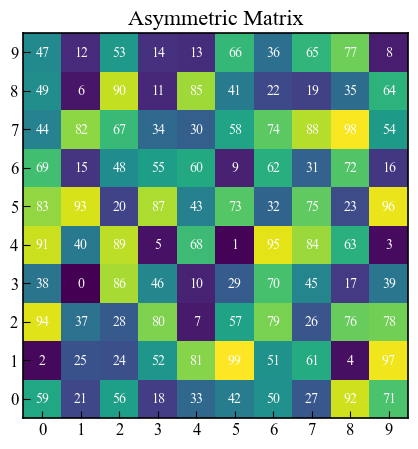

/Users/carloseduardofalandes/Documents/master/gpa-temp/src/gpa/gpa.py:260: UserWarning: magnitude_threshold is greater than 0.15. This may remove a large number of gradient vectors and affect the GPA results.
  warnings.warn(
/Users/carloseduardofalandes/Documents/master/gpa-temp/src/gpa/gpa.py:284: UserWarning: angle_tolerance is greater than pi radians. This may cause a large number of gradient vectors to be considered approximately opposite.
  warnings.warn(


{'G1': 1.2777777777777777, 'G2': np.float32(1.8060669), 'G3': None, 'G4': None}

In [21]:
plot_matrix(
    asymmetric,
    "Asymmetric Matrix"
)

gpaObject = GPA(asymmetric)

results = gpaObject.evaluate(magnitude_threshold=0.01, angle_tolerance=5)

results

### Gradient Components

The two components of the gradient field are visualized independently.

- \(G_x\): gradient component along the horizontal direction.
- \(G_y\): gradient component along the vertical direction.

Gradient X:


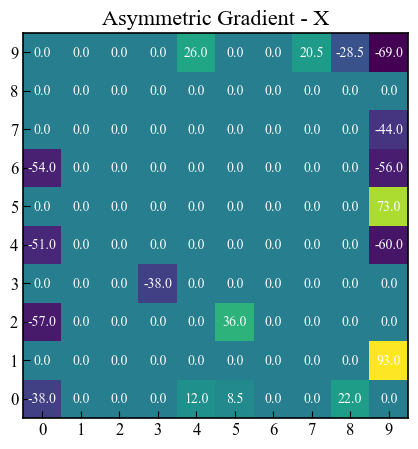

Gradient Y:


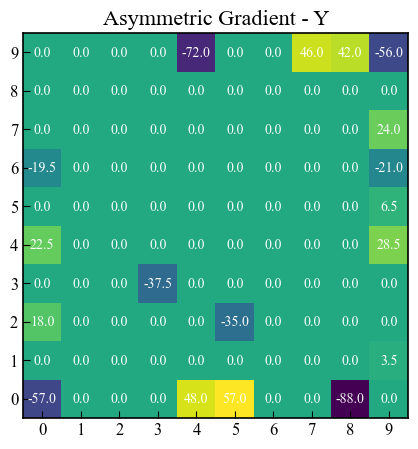

In [22]:
print("Gradient X:")
plot_matrix(
    gpaObject.gradient_asymmetric_dx,
    "Asymmetric Gradient - X"
)

print("Gradient Y:")
plot_matrix(
    gpaObject.gradient_asymmetric_dy,
    "Asymmetric Gradient - Y"
)

## Symmetry Filtering

GPA identifies approximately radially symmetric gradient-vector pairs and removes their contribution from the asymmetric gradient field.

The vectors are separated into two groups:

- **Removed vectors:** vectors identified as radially symmetric.
- **Remaining asymmetric vectors:** vectors that remain after the symmetry filtering.

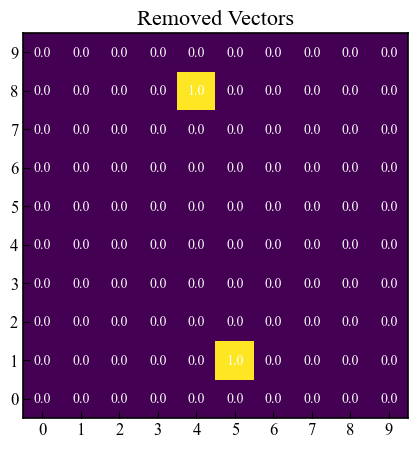

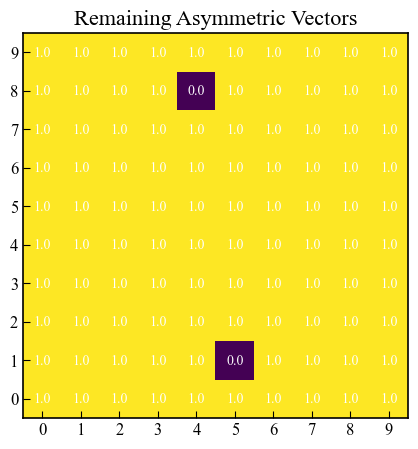

In [18]:
removed_matrix = np.zeros_like(asymmetric, dtype=np.float32)
nremoved_matrix = np.zeros_like(asymmetric, dtype=np.float32)

if hasattr(gpaObject, "removedP"):
    for y, x in gpaObject.removedP:
        removed_matrix[y, x] = 1.0

if hasattr(gpaObject, "nremovedP"):
    for y, x in gpaObject.nremovedP:
        nremoved_matrix[y, x] = 1.0

plot_matrix(
    removed_matrix,
    "Removed Vectors"
)

plot_matrix(
    nremoved_matrix,
    "Remaining Asymmetric Vectors"
)

### Vector Classification

The resulting masks show which spatial positions belong to each group.

This separation is used in the calculation of the asymmetric-vector count \(V_A\) and the GPA parameter \(G_2\).

## Vectorial Diversity and $(G_2)$

The remaining asymmetric gradient vectors are used to calculate the vectorial diversity $D$.

$
D =
\frac{
\left|\sum_i \mathbf{V}_i\right|
}{
\sum_i |\mathbf{V}_i|
}
$

where $\mathbf{V}_i=(G_{x,i},G_{y,i})$ is an asymmetric gradient vector.

The quantity \(D\) measures the global directional alignment of the remaining gradient vectors:

- $(D \approx 1)$: vectors are strongly aligned.
- $(D \approx 0)$: vector directions largely cancel each other.

The $G_2$ parameter is then calculated as

$
G_2 =
\frac{V_A}{V}(2-D),
$

where $V_A$ is the number of remaining asymmetric vectors and $V$ is the number of vectors considered above the magnitude threshold.

### Direct Calculation

The following calculation reproduces the $D$ and $G_2$ quantities directly from the gradient field.

This provides a transparent view of the quantities used in the GPA calculation.

In [19]:
gx = gpaObject.gradient_asymmetric_dx
gy = gpaObject.gradient_asymmetric_dy

magnitudes = np.sqrt(gx**2 + gy**2)

sum_gx = np.sum(gx)
sum_gy = np.sum(gy)

vector_sum = np.sqrt(
    sum_gx**2 +
    sum_gy**2
)

magnitude_sum = np.sum(magnitudes)

D = vector_sum / magnitude_sum if magnitude_sum > 0 else 0.0

G2 = (
    gpaObject.totalAssimetric / gpaObject.totalVet
) * (2.0 - D)

print(f"VA = {gpaObject.totalAssimetric}")
print(f"V  = {gpaObject.totalVet}")
print(f"D  = {D:.6f}")
print(f"G2 = {G2:.6f}")

1.8504796

VA = 98
V  = 100
D  = 0.064379
G2 = 1.896909


1.8504796

## GPA Visualizations

GPA provides complementary visualizations of the gradient field and its asymmetric component.

- `plot_gradient_field()` — original gradient field.
- `plot_asymmetric_gradient_field()` — remaining asymmetric gradient field.
- `plot_delaunay_triangulation()` — spatial organization of the asymmetric vectors.

These visualizations help inspect how the scalar field is represented by gradient vectors and how the symmetry filtering changes the resulting field.

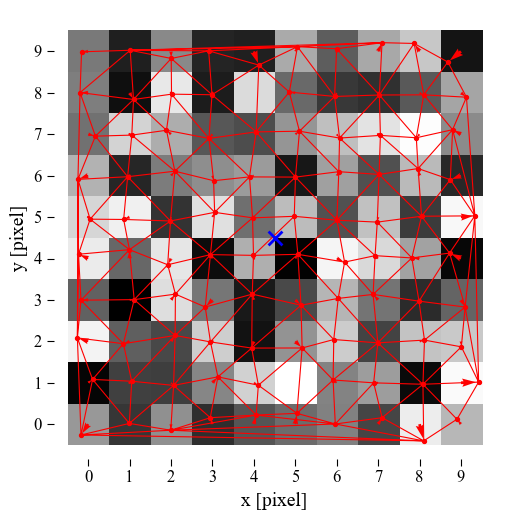

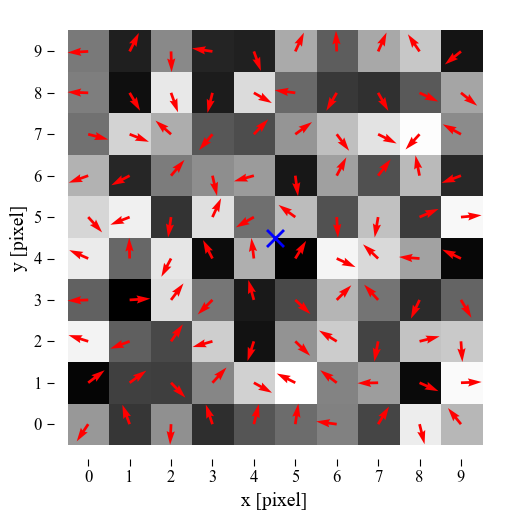

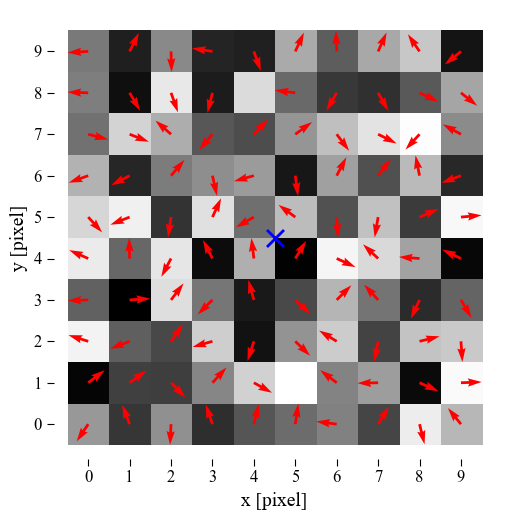

In [20]:
gpaObject.plot_delaunay_triangulation()

gpaObject.plot_gradient_field()

gpaObject.plot_asymmetric_gradient_field()